**This cell imports pandas, numpy, scipy.stats and matplotlib, brings in the helpers from src/, and loads the two daily portfolio return series I saved at the end of notebook 01.**

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
from scipy import stats         # for fitting Normal and Student-t and for the t-PDF / norm-PDF curves later
import matplotlib.pyplot as plt

from src.config import PROCESSED_DATA_DIR
from src.var_methods import compute_all_static          # runs all four static Var/ES methods on 252-day rolling window
from src.data_utils import read_panel

# Load the equal-weighted portfolio return series saved by notebook 1
us = read_panel(PROCESSED_DATA_DIR / "us_portfolio.parquet")["return"]
india = read_panel(PROCESSED_DATA_DIR / "india_portfolio.parquet")["return"]

print(f"US: {len(us)} days")
print(f"India: {len(india)} days")

US: 4023 days
India: 3949 days


**This cell runs the four static VaR/ES methods (Historical Simulation, Normal, Student's t, and Monte Carlo) on a 252-day rolling window for each market at both the 95% and 99% confidence levels.** 

**This is the heaviest computation in the project, it will take approximately around 25–30 minutes because Monte Carlo simulation runs on every rolling window.**

In [2]:
print("Computing US 95% VaR/ES...")
us_results_95 = compute_all_static(us, 0.95)    # rolling-window VaR/ES at 95% for all four static methods in the US market

print("Computing US 99% VaR/ES...")
us_results_99 = compute_all_static(us, 0.99)    # rolling-window VaR/ES at 99% for all four static methods in the US market

print("Computing India 95% VaR/ES...")
india_results_95 = compute_all_static(india, 0.95)      # rolling-window VaR/ES at 95% for all four static methods in the India market

print("Computing India 99% VaR/ES...")
india_results_99 = compute_all_static(india, 0.99)      # rolling-window VaR/ES at 99% for all four static methods in the India market

print("Done")
us_results_95.tail()
india_results_95.tail()

Computing US 95% VaR/ES...
Computing US 99% VaR/ES...
Computing India 95% VaR/ES...
Computing India 99% VaR/ES...
Done


,historical_var,historical_es,normal_var,normal_es,student_t_var,student_t_es,monte_carlo_var,monte_carlo_es
date,,,,,,,,
2025-12-24,0.011047,0.016406,0.012103,0.015262,0.013908,0.026614,0.012498,0.017234
2025-12-26,0.011047,0.016406,0.012064,0.015218,0.013828,0.026569,0.011248,0.016791
2025-12-29,0.010726,0.016083,0.011925,0.015055,0.013718,0.026358,0.010882,0.015855
2025-12-30,0.010726,0.016083,0.011950,0.015080,0.013699,0.026155,0.010882,0.015703
2025-12-31,0.010726,0.016083,0.011943,0.015073,0.013697,0.026199,0.010541,0.015188


**This cell builds a small helper function that pulls the most recent VaR and ES estimate from each method into one table, so I can see how the four methods compare on a single representative day.**

In [3]:
def result_table(df_95, df_99):
    # Pull the last row from each results DataFrame and split columns by 'var' and 'es'
    return pd.DataFrame({
        "Method": ["Historical", "Normal", "Student's t", "Monte Carlo"],
        "VaR 95%": df_95[[c for c in df_95.columns if "var" in c]].iloc[-1].values,
        "ES 95%": df_95[[c for c in df_95.columns if "es" in c]].iloc[-1].values,
        "VaR 99%": df_99[[c for c in df_99.columns if "var" in c]].iloc[-1].values,
        "ES 99%": df_99[[c for c in df_99.columns if "es" in c]].iloc[-1].values,
    })
    
print("US - end of sample:")
print(result_table(us_results_95, us_results_99).round(4))
print()
print("India = end of sample:")
print(result_table(india_results_95, india_results_99).round(4))

US - end of sample:
        Method  VaR 95%  ES 95%  VaR 99%  ES 99%
0   Historical   0.0131  0.0233   0.0278  0.0470
1       Normal   0.0155  0.0196   0.0222  0.0256
2  Student's t   0.0117  0.0197   0.0232  0.0359
3  Monte Carlo   0.0134  0.0224   0.0320  0.0470

India = end of sample:
        Method  VaR 95%  ES 95%  VaR 99%  ES 99%
0   Historical   0.0107  0.0161   0.0190  0.0242
1       Normal   0.0119  0.0151   0.0170  0.0196
2  Student's t   0.0137  0.0262   0.0301  0.0551
3  Monte Carlo   0.0105  0.0152   0.0172  0.0226


**Findings:**

- The four methods produce broadly similar 95% numbers but spread out at 99%. 
- Normal and Historical gives small 95% VaR/ES while Student-t gives the largest VaR and ES in the India market because it assumes fatter tails.
- Monte Carlo is within the same general range but noisier because it resamples the return window.

**This cell plots the US daily return series with the Historical and Normal VaR thresholds at both 95% and 99% drawn on top. Plotting negative VaR puts the threshold on the same axis as the returns, so a violation is any day where the grey return line dips below the colored VaR line.**

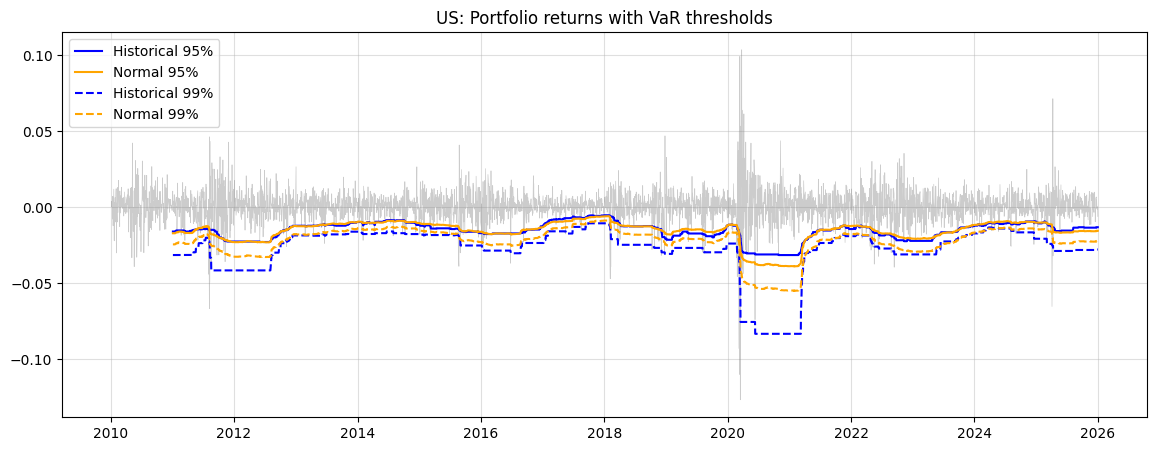

In [4]:
plt.figure(figsize = (14, 5)) 
plt.plot(us.index, us, color = "gray", alpha = 0.4, linewidth = 0.5)
plt.plot(us_results_95.index, -us_results_95["historical_var"], color = "blue", label = "Historical 95%")
plt.plot(us_results_95.index, -us_results_95["normal_var"], color = "orange", label = "Normal 95%")
plt.plot(us_results_99.index, -us_results_99["historical_var"], color = "blue", linestyle = "--", label = "Historical 99%")
plt.plot(us_results_99.index, -us_results_99["normal_var"], color = "orange", linestyle = "--", label = "Normal 99%")
plt.title("US: Portfolio returns with VaR thresholds")
plt.legend()
plt.grid(alpha = 0.4)
plt.show()

**Findings:**

- The thresholds adapt slowly because the 252-day rolling window includes a year of history, the VaR lines smooth over short-lived spikes. 
- During the COVID 2020 selloff, you can see the thresholds widen only after the actual returns have already blown through them
- Historical 99% is generally below Normal 99% because the 99th percentile of the actual return history is more extreme than the 99th percentile of a fitted Normal, since the actual data has fat tails the Normal misses.

**This cell fits a Normal distribution and a Student-t distribution to the most recent 252 days of returns for each market, then plots the histogram against both fitted PDFs: linear y-axis and a log y-axis.**

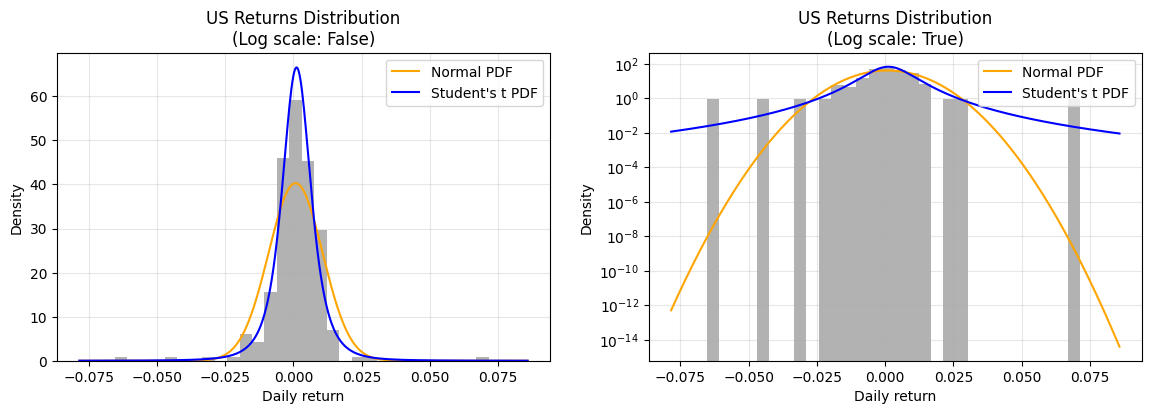

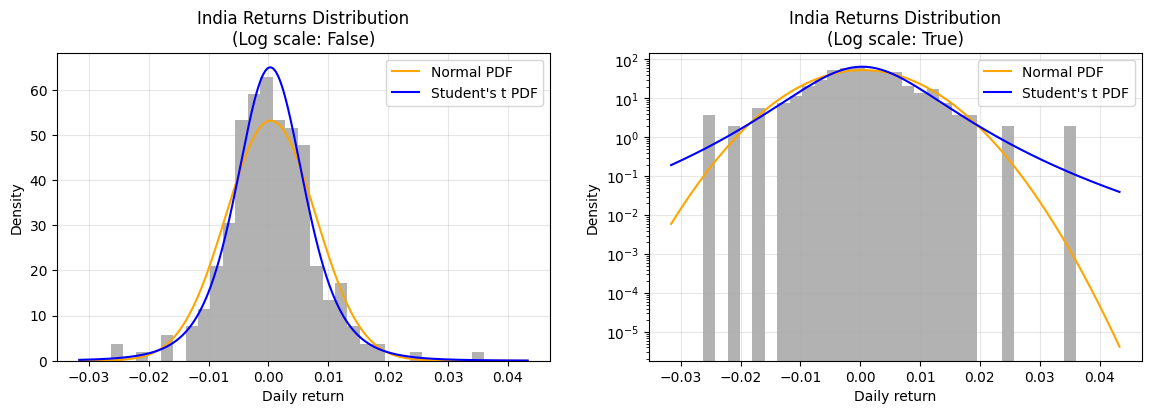

In [5]:
def plot_fit(returns, market_name):
    win = returns.iloc[-252:].values        # most recent 252 trading days 
    mu, sigma = win.mean(), win.std()       # Normal MLE: Just sample mean and standard deviation
    df, loc, scale = stats.t.fit(win)       # Student-t MLE: Fits degrees of freedom
    x = np.linspace(win.min() * 1.2, win.max() * 1.2, 500)      
    
    fig, axes = plt.subplots(1, 2, figsize = (14,4))
    for ax, log_y in zip(axes, [False, True]):
        ax.hist(win, bins = 30, density = True, alpha = 0.6, color = "gray")
        ax.plot(x, stats.norm.pdf(x, mu, sigma), color = "orange", label = "Normal PDF")
        ax.plot(x, stats.t.pdf(x, df, loc, scale), color = "blue", label = "Student's t PDF")
        ax.set_title(f"{market_name} Returns Distribution\n(Log scale: {log_y})")
        ax.set_xlabel("Daily return")
        ax.set_ylabel("Density")
        if log_y:
            ax.set_yscale("log")
        ax.legend()
        ax.grid(alpha = 0.3)
    plt.show()
    
plot_fit(us, "US")
plot_fit(india, "India")

**Findings:**

- On the linear panel: The Normal and Student-t curves look almost identical near the peak. It shows that most days are net near-zero returns and either fit captures that fine.
- On the log panel: The two curves separate clearly in the tails. The Student-t's tail decays more slowly than the Normal's, so for any extreme return on the x-axis the Student-t assigns higher probability than the Normal does.
- The Normal is missing density in the tails and its VaR threshold is too shallow, so it under-warns about extreme losses.

**This cell writes the four static results DataFrames to data/processed/ as Parquet. Notebooks 04 and 05 read these files directly.**

In [6]:
us_results_95.to_parquet(PROCESSED_DATA_DIR / "us_var_static_95.parquet")
us_results_99.to_parquet(PROCESSED_DATA_DIR / "us_var_static_99.parquet")
india_results_95.to_parquet(PROCESSED_DATA_DIR / "india_var_static_95.parquet")
india_results_99.to_parquet(PROCESSED_DATA_DIR / "india_var_static_99.parquet")

print("Parquets saved successfully!")

Parquets saved successfully!
